In [1]:
import scenicplus

In [2]:
scenicplus.__version__

'1.0a1'

In [3]:
import os
os.chdir("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/IPC")

In [4]:
ls data

ipc.h5ad


In [5]:
!mkdir -p scplus_pipeline
!scenicplus init_snakemake --out_dir scplus_pipeline 

2026-03-10 20:31:48,833 SCENIC+      INFO     Creating snakemake folder in: scplus_pipeline


In [ ]:
# # Specify database:
# feather_database_url='https://resources.aertslab.org/cistarget/databases/homo_sapiens/hg38/screen/mc_v10_clust/region_based/hg38_screen_v10_clust.regions_vs_motifs.rankings.feather'
# # feather_database_url='https://resources.aertslab.org/cistarget/databases/homo_sapiens/hg38/screen/mc_v10_clust/region_based/hg38_screen_v10_clust.regions_vs_motifs.scores.feather'
# feather_database="${feather_database_url##*/}"

# # Download database directly (with wget or curl):
# wget "${feather_database_url}"

# Run pipeline
Once the config file is filled in the pipeline can be run.

In [4]:
cd scplus_pipeline/Snakemake/

/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/Neuron/scplus_pipeline/Snakemake


In [5]:
ls

config/  workflow/


In [ ]:
snakemake --cores 20

# Main outputs
The main output of the pipeline is the scplusmdata.h5mu file. This is a MuData file containing the eRegulons and enrichment scores.

In [13]:
%load_ext autoreload
%autoreload 2
import os
os.chdir("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/Neuron")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
import mudata
scplus_mdata = mudata.read("outs/scplusmdata.h5mu")

/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/pyt

In [15]:
scplus_mdata

MuData object with n_obs × n_vars = 10248 × 199435
  uns:	'direct_e_regulon_metadata', 'extended_e_regulon_metadata'
  6 modalities
    scRNA_counts:	10248 x 36601
      obs:	'sample2', 'barcode2', 'celltype'
      var:	'gene_ids', 'feature_types'
    scATAC_counts:	10248 x 162500
      obs:	'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc', 'sample_id', 'sample2', 'barcode2', 'celltype'
      var:	'Chromosome', 'Start', 'End', 'Width', 'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc'
    direct_gene_based_AUC:	10248 x 92
    direct_region_based_AUC:	10248 x 92
    extended_gene_based_AUC:	10248 x 75
    extended_region_based_AUC:	10248 x 75

In [16]:
scplus_mdata.uns

{'direct_e_regulon_metadata':                           Region     Gene  importance_R2G   rho_R2G  \
 0        chr20:37416066-37416567     NNAT        0.051961  0.255879   
 1        chr18:49584337-49584838    RPL17        0.121065  0.091964   
 2         chr8:60908747-60909248     CHD7        0.049249  0.389336   
 3        chr14:77143019-77143520  ZDHHC22        0.086654  0.065118   
 4        chr11:35919279-35919780  LDLRAD3        0.060242  0.266976   
 ...                          ...      ...             ...       ...   
 31852    chr17:79034094-79034595   RBFOX3        0.004771 -0.200909   
 31853    chr11:57432063-57432564    P2RX3        0.010900 -0.134299   
 31854     chr2:23502108-23502609   KLHL29        0.005732 -0.068601   
 31855     chr3:25527756-25528257     RARB        0.001527 -0.195125   
 31856  chr13:109275287-109275788    MYO16        0.000702 -0.271017   
 
        importance_x_rho  importance_x_abs_rho     TF  is_extended  \
 0              0.013296           

In [17]:
scplus_mdata.uns["direct_e_regulon_metadata"]['Gene_signature_name'].value_counts()

NFIA_direct_+/+_(1390g)    3207
RFX3_direct_+/+_(925g)     1583
SOX2_direct_+/+_(797g)     1454
NFIB_direct_+/+_(677g)     1431
SOX6_direct_+/+_(541g)     1050
                           ... 
FOXM1_direct_+/-_(15g)       15
OLIG1_direct_+/+_(13g)       13
SREBF1_direct_+/-_(11g)      13
ETV5_direct_+/+_(12g)        12
MXI1_direct_+/+_(12g)        12
Name: Gene_signature_name, Length: 92, dtype: int64

In [18]:
import pandas as pd

# Load data
df = scplus_mdata.uns["direct_e_regulon_metadata"]

# Parse query interval
query_region = "chr21:33115188-33118388"
query_chr, query_range = query_region.split(':')
query_start, query_end = map(int, query_range.split('-'))

# Overlap test helper
def check_overlap(region_str):
    """Check whether an interval overlaps the query region"""
    chr_part, range_part = region_str.split(':')
    start, end = map(int, range_part.split('-'))
    
    # Same chromosome and overlapping ranges
    return (chr_part == query_chr and 
            not (end < query_start or start > query_end))

# Apply filter
overlapping_rows = df[df['Region'].apply(check_overlap)]

# Print count
print(f"Found {len(overlapping_rows)} overlapping regions:")
overlapping_rows

Found 22 overlapping regions:


,Region,Gene,importance_R2G,rho_R2G,importance_x_rho,importance_x_abs_rho,TF,is_extended,eRegulon_name,Gene_signature_name,Region_signature_name,importance_TF2G,regulation,rho_TF2G,triplet_rank
11705,chr21:33115804-33116305,OLIG1,0.028125,0.585335,0.016462,0.016462,OLIG2,False,OLIG2_direct_+/+,OLIG2_direct_+/+_(255g),OLIG2_direct_+/+_(433r),6.587794,1,0.434670,2353
11939,chr21:33115804-33116305,IFNAR2,0.025162,0.095588,0.002405,0.002405,OLIG2,False,OLIG2_direct_+/+,OLIG2_direct_+/+_(255g),OLIG2_direct_+/+_(433r),0.414147,1,0.118764,30452
11977,chr21:33115804-33116305,OLIG2,0.025499,0.355927,0.009076,0.009076,OLIG2,False,OLIG2_direct_+/+,OLIG2_direct_+/+_(255g),OLIG2_direct_+/+_(433r),6.587804,1,1.000000,2478
16606,chr21:33117360-33117861,OLIG2,0.030482,0.367876,0.011214,0.011214,SOX10,False,SOX10_direct_+/+,SOX10_direct_+/+_(272g),SOX10_direct_+/+_(765r),1.604272,1,0.224867,29460
16621,chr21:33115804-33116305,OLIG1,0.028125,0.585335,0.016462,0.016462,SOX10,False,SOX10_direct_+/+,SOX10_direct_+/+_(272g),SOX10_direct_+/+_(765r),2.745954,1,0.274688,19001
16636,chr21:33116624-33117125,OLIG1,0.104305,0.600231,0.062607,0.062607,SOX10,False,SOX10_direct_+/+,SOX10_direct_+/+_(272g),SOX10_direct_+/+_(765r),2.745954,1,0.274688,2434
16752,chr21:33116624-33117125,IFNAR2,0.074284,0.111564,0.008287,0.008287,SOX10,False,SOX10_direct_+/+,SOX10_direct_+/+_(272g),SOX10_direct_+/+_(765r),0.965845,1,0.110104,11240
16861,chr21:33116624-33117125,OLIG2,0.089638,0.376923,0.033787,0.033787,SOX10,False,SOX10_direct_+/+,SOX10_direct_+/+_(272g),SOX10_direct_+/+_(765r),1.604272,1,0.224867,6021
16984,chr21:33117360-33117861,OLIG1,0.059076,0.592454,0.035000,0.035000,SOX10,False,SOX10_direct_+/+,SOX10_direct_+/+_(272g),SOX10_direct_+/+_(765r),2.745954,1,0.274688,17078
17039,chr21:33115804-33116305,IFNAR2,0.025162,0.095588,0.002405,0.002405,SOX10,False,SOX10_direct_+/+,SOX10_direct_+/+_(272g),SOX10_direct_+/+_(765r),0.965845,1,0.110104,25420


In [19]:
import pandas as pd

# Load data
df = scplus_mdata.uns["extended_e_regulon_metadata"]

# Parse query interval
query_region = "chr21:33115188-33118388"
query_chr, query_range = query_region.split(':')
query_start, query_end = map(int, query_range.split('-'))

# Apply filter
overlapping_rows = df[df['Region'].apply(check_overlap)]

# Print count
print(f"Found {len(overlapping_rows)} overlapping regions:")
overlapping_rows

Found 5 overlapping regions:


,Region,Gene,importance_R2G,rho_R2G,importance_x_rho,importance_x_abs_rho,TF,is_extended,eRegulon_name,Gene_signature_name,Region_signature_name,importance_TF2G,regulation,rho_TF2G,triplet_rank
5129,chr21:33115804-33116305,OLIG2,0.025499,0.355927,0.009076,0.009076,OLIG1,True,OLIG1_extended_+/+,OLIG1_extended_+/+_(274g),OLIG1_extended_+/+_(407r),7.297096,1,0.434670,720
5325,chr21:33115804-33116305,OLIG1,0.028125,0.585335,0.016462,0.016462,OLIG1,True,OLIG1_extended_+/+,OLIG1_extended_+/+_(274g),OLIG1_extended_+/+_(407r),10.323915,1,1.000000,125
5478,chr21:33115804-33116305,IFNAR2,0.025162,0.095588,0.002405,0.002405,OLIG2,True,OLIG2_extended_+/+,OLIG2_extended_+/+_(234g),OLIG2_extended_+/+_(354r),0.414147,1,0.118764,18209
5529,chr21:33115804-33116305,OLIG2,0.025499,0.355927,0.009076,0.009076,OLIG2,True,OLIG2_extended_+/+,OLIG2_extended_+/+_(234g),OLIG2_extended_+/+_(354r),6.587804,1,1.000000,1209
5703,chr21:33115804-33116305,OLIG1,0.028125,0.585335,0.016462,0.016462,OLIG2,True,OLIG2_extended_+/+,OLIG2_extended_+/+_(234g),OLIG2_extended_+/+_(354r),6.587794,1,0.434670,1117


# Downstream analysis

## eRegulon dimensionality reduction
The eRegulon enrichment scores can be used to perform dimensionality reductions

In [ ]:
palette={
    'NPC': '#faa275',
    'dIPC': '#34a0a4',
    'dIPC_switching': '#34a0a4',
    'dIPC_switched': '#34a0a4',
    'OPC': '#168aad', 
    'ExN_naive': '#BF3131',
    'InN_naive': '#BA6EAC'
}

/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored


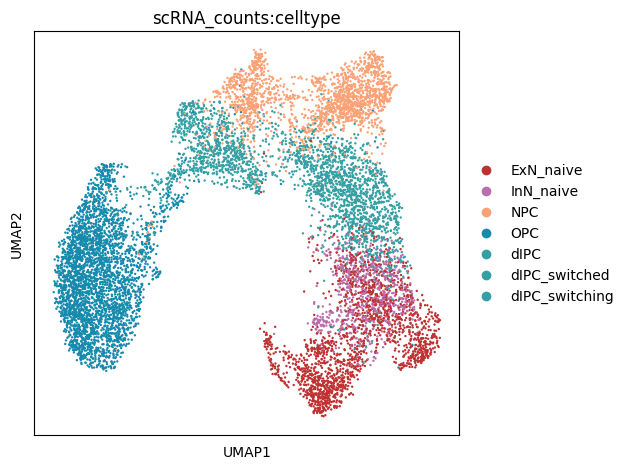

In [21]:
import scanpy as sc
import anndata
eRegulon_gene_AUC = anndata.concat(
    [scplus_mdata["direct_gene_based_AUC"], scplus_mdata["extended_gene_based_AUC"]],
    axis = 1,
)
eRegulon_gene_AUC.obs = scplus_mdata.obs.loc[eRegulon_gene_AUC.obs_names]
sc.pp.neighbors(eRegulon_gene_AUC, use_rep = "X")
sc.tl.umap(eRegulon_gene_AUC)
sc.pl.umap(eRegulon_gene_AUC, color = "scRNA_counts:celltype", palette=palette)

## eRegulon specificity score

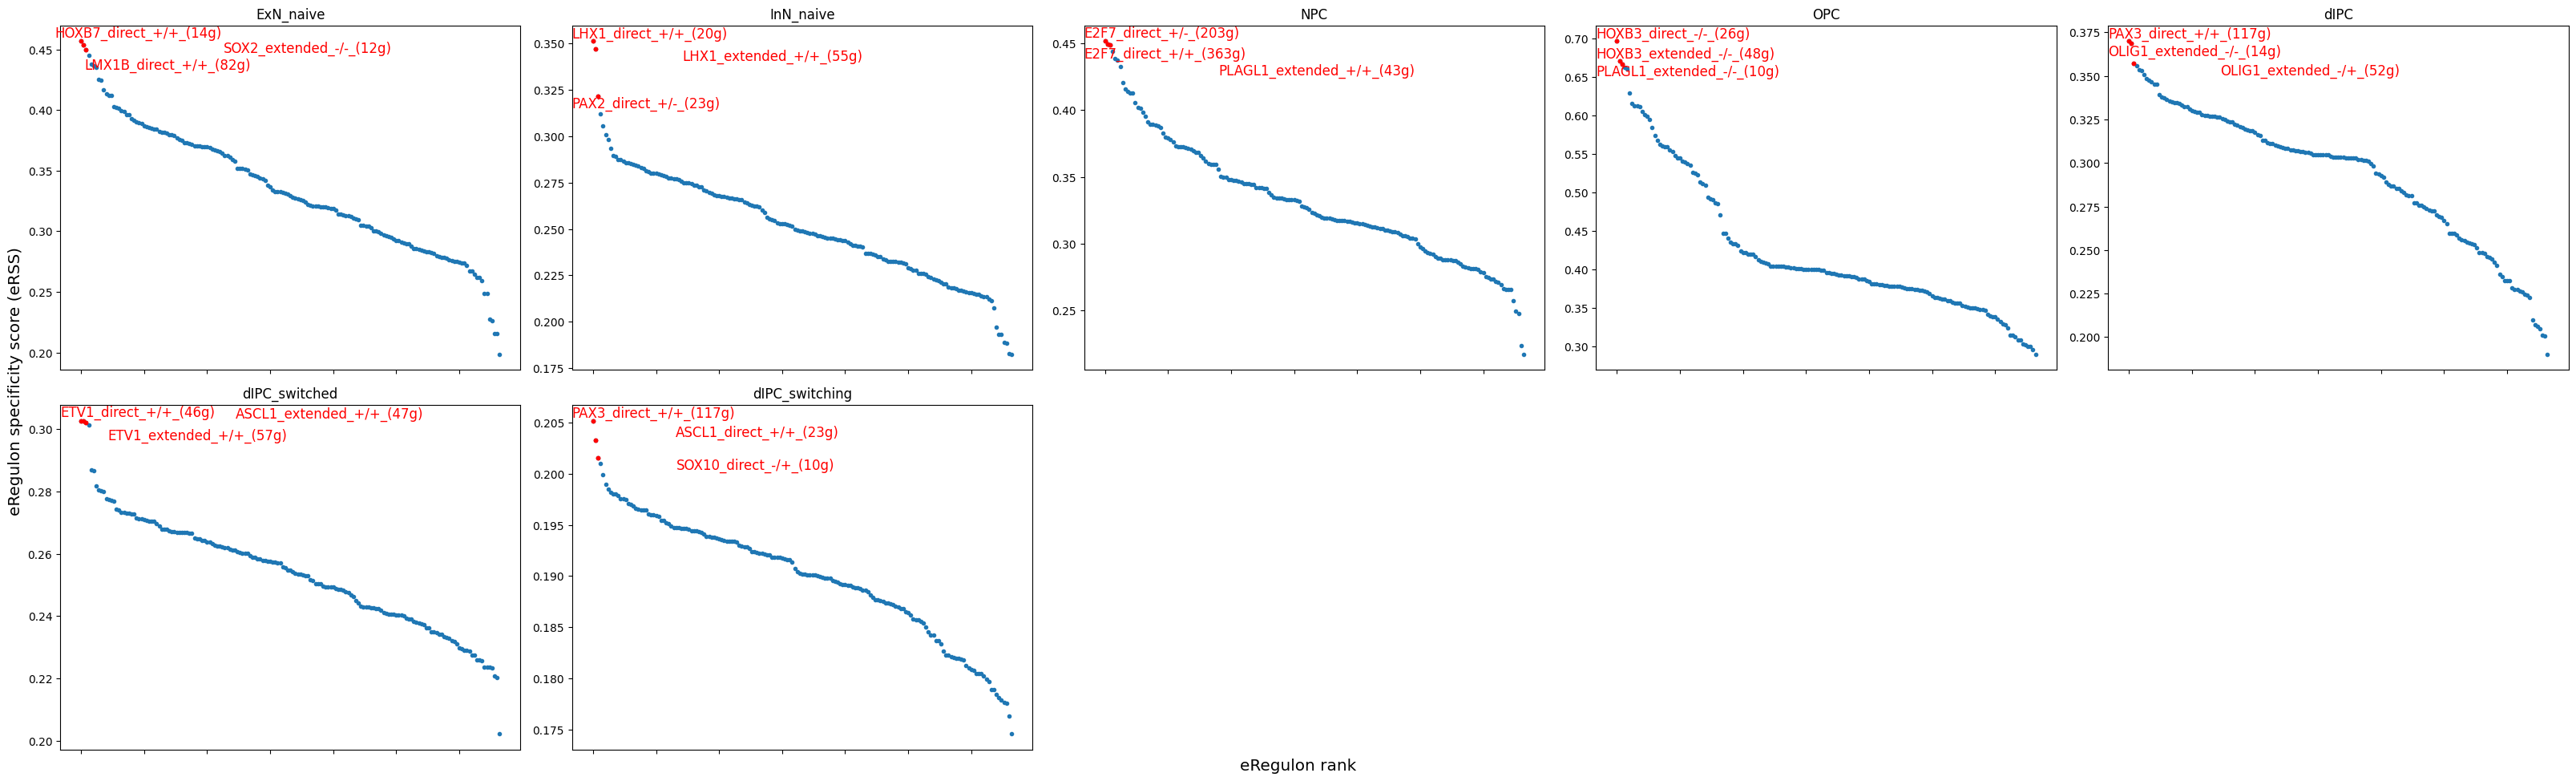

In [22]:
from scenicplus.RSS import (regulon_specificity_scores, plot_rss)
rss = regulon_specificity_scores(
    scplus_mudata = scplus_mdata,
    variable = "scRNA_counts:celltype",
    modalities = ["direct_gene_based_AUC", "extended_gene_based_AUC"]
)
plot_rss(
    data_matrix = rss,
    top_n = 3,
    num_columns = 5
)

## Heatmap dotplot
We can draw a heatmap where the color represent target gene enrichment and the dotsize target region enrichment.

In [19]:
from scenicplus.plotting.dotplot import heatmap_dotplot
heatmap_dotplot(
    scplus_mudata = scplus_mdata,
    color_modality = "direct_gene_based_AUC",
    size_modality = "direct_region_based_AUC",
    group_variable = "scRNA_counts:celltype",
    group_variable_order = ['NPC', 'dIPC','ExN_naive', 'InN_naive', 'dIPC_switching', 'dIPC_switched', 'OPC'][::-1],
    eRegulon_metadata_key = "direct_e_regulon_metadata",
    color_feature_key = "Gene_signature_name",
    size_feature_key = "Region_signature_name",
    feature_name_key = "eRegulon_name",
    sort_data_by = "direct_gene_based_AUC",
    orientation = "horizontal",
    figsize = (15, 10),
    save='./plot/eRegulon_dotplot.svg'
)

/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 15 x 10 in image.
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: ./plot/eRegulon_dotplot.svg


In [23]:
scplus_mdata

MuData object with n_obs × n_vars = 10248 × 199435
  uns:	'direct_e_regulon_metadata', 'extended_e_regulon_metadata'
  6 modalities
    scRNA_counts:	10248 x 36601
      obs:	'sample2', 'barcode2', 'celltype'
      var:	'gene_ids', 'feature_types'
    scATAC_counts:	10248 x 162500
      obs:	'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc', 'sample_id', 'sample2', 'barcode2', 'celltype'
      var:	'Chromosome', 'Start', 'End', 'Width', 'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc'
    direct_gene_based_AUC:	10248 x 92
    direct_region_based_AUC:	10248 x 92
    extended_gene_based_AUC:	10248 x 75
    extended_region_based_AUC:	10248 x 75

In [22]:
scplus_mdata.uns['direct_e_regulon_metadata']['eRegulon_name'].value_counts()

NFIA_direct_+/+      3207
RFX3_direct_+/+      1583
SOX2_direct_+/+      1454
NFIB_direct_+/+      1431
SOX6_direct_+/+      1050
                     ... 
FOXM1_direct_+/-       15
OLIG1_direct_+/+       13
SREBF1_direct_+/-      13
ETV5_direct_+/+        12
MXI1_direct_+/+        12
Name: eRegulon_name, Length: 92, dtype: int64

# Track Plot

In [25]:
from scenicplus.grn_builder.modules import create_emodules
import pandas as pd
# 1. Load region–gene table
region_to_gene = pd.read_csv("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/Neuron/outs/region_to_gene_adj.tsv", sep="\t")

# 2. Load cistromes (often h5ad)
cistromes = sc.read_h5ad("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/Neuron/outs/cistromes_direct.h5ad")

# 3. Parameters
is_extended = False  # True/False depends on extended vs standard model
temp_dir = "/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/Neuron/tmp/"

# 4. create_emodules -> eRegulons
relevant_tfs, eRegulons = create_emodules(
    region_to_gene=region_to_gene,
    cistromes=cistromes,
    is_extended=is_extended,
    temp_dir=temp_dir,
    n_cpu=10,  # Parallel workers
)

100%|██████████| 10/10 [02:07<00:00, 12.77s/it]


In [26]:
import dill
from scenicplus.scenicplus_class import mudata_to_scenicplus
scplus_obj = mudata_to_scenicplus(
    mdata = scplus_mdata,
    path_to_cistarget_h5 = "/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/Neuron/outs/ctx_results.hdf5",
    path_to_dem_h5 = "/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/Neuron/outs/dem_results.hdf5"
)

In [27]:
scplus_obj.uns["eRegulons"] = eRegulons

In [28]:
dill.dump(scplus_obj, open('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/Neuron/outs/scplus_obj.pkl', 'wb'))

In [ ]:
import dill
with open('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/Neuron/outs/scplus_obj.pkl', 'rb') as f:
    scplus_obj = dill.load(f)

In [29]:
from scenicplus.utils import get_interaction_pr
import pyranges as pr
import pandas as pd

region_to_gene = pd.read_csv("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/Neuron/outs/region_to_gene_adj.tsv",sep = '\t')

scplus_obj.uns['region_to_gene'] = region_to_gene.copy()

In [31]:
pr_consensus_bed = pr.read_bed('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/Neuron/outs/consensus_peaks.bed')
pr_interact = get_interaction_pr(scplus_obj, 'hsapiens', 'hg38', inplace = False, subset_for_eRegulons_regions = True, region_to_gene_key = 'region_to_gene',eRegulons_key = 'eRegulons',)

/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/pybiomart/dataset.py:269: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/scenicplus/utils.py:664: RuntimeWarning: invalid value encountered in divide
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/scenicplus/utils.py:678: RuntimeWarning: invalid value encountered in divide


In [32]:
pr_consensus_bed

,Chromosome,Start,End
0,chr1,817093,817594
1,chr1,817859,818360
2,chr1,827302,827803
3,chr1,849801,850302
4,chr1,858640,859141
...,...,...,...
162524,chrY,19578507,19579008
162525,chrY,19744511,19745012
162526,chrY,19745188,19745689
162527,chrY,20559881,20560382


In [33]:
bigwig_dir = '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/Neuron/bigwig'
bw_dict = {x.replace('.bw', ''): os.path.join(bigwig_dir, x) for x in os.listdir(bigwig_dir) if '.bw' in x}

"NPC_proliferative", "NPC", "dIPC", "vIPC", "dorsal_glia", "ventral_glia", 
"ExN_naive", "ExN_immature_1", "ExN_immature_2", "ExN_immature_3", "ExN_mature_1", "ExN_mature_2", "ExN_mature_3", 
"InN_naive", "InN_immature_1", "InN_immature_2", "InN_mature_1", "InN_mature_2", "InN_ventral_like", "ventral_unknow", 
"v0_1", "v2a_b", "MN1", "MN2", "OPC", "Ependymal", "FP", "RP", "Microglia", "VLMC", "EC"


In [34]:
bw_dict_toshow = {
    k: bw_dict[k]
    for k in ["NPC", "dIPC", "ExN_naive", "InN_naive", "dIPC_switching", "dIPC_switched", "OPC"]  # Cell types to show
}

In [35]:
gtf_file = "/cluster2/huanglab/jiamao/Apps/refdata-cellranger-arc-GRCh38-2020-A-2.0.0/genes/genes.gtf.gz"
pr_gtf = pr.read_gtf(gtf_file)

In [36]:
# BED missing name column — fill
import numpy as np
np.bool = bool
pr_genes = pr_gtf[pr_gtf.Feature == "gene"]

# Intersect intervals with genes
# Intersection: BED overlaps gene bodies
overlap = pr_consensus_bed.join(pr_genes, how="left")

# Attach gene_name from GTF
# Check GTF attribute (gene_name vs gene_id)
# overlap.df: BED columns + GTF annotations
df = overlap.df

# gene_name if overlap; else "." or "NA"
df["Name"] = df["gene_name"].fillna(".")

# Keep BED3 + name column
bed_with_name = df[["Chromosome", "Start", "End", "Name"]]

/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/pyranges/methods/join.py:87: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/pyranges/methods/join.py:88: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/pyranges/methods/join.py:87: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/pyranges/methods/join.py:88: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
/cluster2/huanglab/jiamao/conda/envs/scenicp

In [37]:
bed_with_name.to_csv('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/Neuron/outs/consensus_peaks_with_name.bed', sep="\t", header=False, index=False)

In [38]:
bed_with_name = pr.read_bed('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/Neuron/outs/consensus_peaks_with_name.bed')

In [39]:
bed_with_name

,Chromosome,Start,End,Name
0,chr1,817093,817594,FAM87B
1,chr1,817859,818360,FAM87B
2,chr1,827302,827803,LINC01128
3,chr1,849801,850302,LINC01128
4,chr1,858640,859141,LINC01128
...,...,...,...,...
179145,chrY,19076709,19077210,TTTY14
179146,chrY,19076709,19077210,AC007244.1
179147,chrY,19744511,19745012,KDM5D
179148,chrY,20559881,20560382,TTTY10


# result

In [9]:
palette={
    'NPC': '#faa275', 
    'dIPC': '#34a0a4',
    'dIPC_switching': '#34a0a4',
    'dIPC_switched': '#34a0a4',
    'OPC': '#168aad', 
    'ExN_naive': '#BF3131',
    'InN_naive': '#BA6EAC'
}

In [1]:
import dill
import pyranges as pr
import pandas as pd
import numpy as np
from scenicplus.utils import get_interaction_pr
import os

with open('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/Neuron/outs/scplus_obj.pkl', 'rb') as f:
    scplus_obj = dill.load(f)

region_to_gene = pd.read_csv("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/Neuron/outs/region_to_gene_adj.tsv",sep = '\t')
scplus_obj.uns['region_to_gene'] = region_to_gene.copy()

pr_consensus_bed = pr.read_bed('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/Neuron/outs/consensus_peaks.bed')
pr_interact = get_interaction_pr(scplus_obj, 'hsapiens', 'hg38', inplace = False, subset_for_eRegulons_regions = True, region_to_gene_key = 'region_to_gene',eRegulons_key = 'eRegulons',)

bigwig_dir = '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/Neuron/bigwig'
bw_dict = {x.replace('.bw', ''): os.path.join(bigwig_dir, x) for x in os.listdir(bigwig_dir) if '.bw' in x}
bw_dict_toshow = {
    k: bw_dict[k]
    for k in ["NPC", "dIPC", "ExN_naive", "InN_naive", "dIPC_switching", "dIPC_switched", "OPC"]  # Cell types to show
}
pr_gtf = pr.read_gtf("/cluster2/huanglab/jiamao/Apps/refdata-cellranger-arc-GRCh38-2020-A-2.0.0/genes/genes.gtf.gz")
bed_with_name = pr.read_bed('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/Neuron/outs/consensus_peaks_with_name.bed')

/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/pybiomart/dataset.py:269: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  result = pd.read_csv(StringIO(response.text), sep='\t')
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/scenicplus/utils.py:664: RuntimeWarning: invalid value encountered in divide
  S = (scores - scores.min()) / (scores.max() - scores.min())
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/scenicplus/utils.py:678: RuntimeWarning: invalid value encountered in divide
  S = (scores - scores.min()) / (scores.max() - scores.min())


In [2]:
pr_region = pr.PyRanges(chromosomes=['chr21'], starts=['32925935'], ends=['33172413']) #188kb
consensus_bed_region_intersect = pr_consensus_bed.intersect(pr_region)
consensus_bed_region_intersect

,Chromosome,Start,End
0,chr21,32930660,32931161
1,chr21,32932768,32933269
2,chr21,32940359,32940860
3,chr21,32949655,32950156
4,chr21,32952265,32952766
5,chr21,32955698,32956199
6,chr21,32956364,32956865
7,chr21,32954937,32955438
8,chr21,32957480,32957981
9,chr21,32965036,32965537


In [11]:
interact_gene = pr_interact[pr_interact.targetName.isin(["ASCL1"])]
interact_gene = interact_gene.apply(lambda x: x[x['value'] > 0.04])
interact_gene

,Chromosome,Start,End,name,score,value,exp,color,sourceChrom,sourceStart,sourceEnd,sourceName,sourceStrand,targetChrom,targetStart,targetEnd,targetName,targetStrand
0,chr12,103043757,103044258,ASCL1_1,0,0.052639,.,#a3cce3,chr12,103044006,103044007,ASCL1_1,.,chr12,102957674,102957675,ASCL1,+
1,chr12,102956194,102956695,ASCL1_1,0,0.053809,.,#9fcae1,chr12,102956443,102956444,ASCL1_1,.,chr12,102957674,102957675,ASCL1,+
2,chr12,102965297,102965798,ASCL1_1,0,0.060599,.,#84bcdb,chr12,102965546,102965547,ASCL1_1,.,chr12,102957674,102957675,ASCL1,+
3,chr12,102966372,102966873,ASCL1_1,0,0.118024,.,#08306b,chr12,102966621,102966622,ASCL1_1,.,chr12,102957674,102957675,ASCL1,+
4,chr12,102951030,102951531,ASCL1_1,0,0.074190,.,#539ecd,chr12,102951279,102951280,ASCL1_1,.,chr12,102957674,102957675,ASCL1,+
5,chr12,102951963,102952464,ASCL1_1,0,0.058735,.,#8cc0dd,chr12,102952212,102952213,ASCL1_1,.,chr12,102957674,102957675,ASCL1,+
6,chr12,103012863,103013364,ASCL1_1,0,0.049642,.,#abd0e6,chr12,103013112,103013113,ASCL1_1,.,chr12,102957674,102957675,ASCL1,+


In [12]:
interact_gene.df.columns

Index(['Chromosome', 'Start', 'End', 'name', 'score', 'value', 'exp', 'color',
       'sourceChrom', 'sourceStart', 'sourceEnd', 'sourceName', 'sourceStrand',
       'targetChrom', 'targetStart', 'targetEnd', 'targetName',
       'targetStrand'],
      dtype='object')

In [13]:
chromosome = interact_gene.df['Chromosome'].iloc[0]
target_gene = interact_gene.df['targetName'].iloc[0]
all_starts = interact_gene.df['Start'].values
all_ends = interact_gene.df['End'].values
min_start = np.min(all_starts)
max_end = np.max(all_ends)
region = f"{chromosome}:{min_start}-{max_end}"
genes_violin_plot = target_gene
region

'chr12:102951030-103044258'

In [14]:
region = 'chr12:102951030-103044258'
genes_violin_plot = 'ASCL1'

In [15]:
pr_interact

,Chromosome,Start,End,name,score,value,exp,color,sourceChrom,sourceStart,sourceEnd,sourceName,sourceStrand,targetChrom,targetStart,targetEnd,targetName,targetStrand
0,chr1,245679781,245680282,KIF26B_1,0,0.003664,.,#fee8de,chr1,245680030,245680031,KIF26B_1,.,chrHSCHR1_1_CTG32_1,245154985,245154986,KIF26B,+
1,chr1,245679781,245680282,SMYD3_1,0,0.025703,.,#c7dcef,chr1,245680030,245680031,SMYD3_1,.,chr1,246507312,246507311,SMYD3,-
2,chr1,14598466,14598967,KAZN_1,0,0.046449,.,#2070b4,chr1,14598715,14598716,KAZN_1,.,chr1,13892792,13892793,KAZN,+
3,chr1,90717795,90718296,BARHL2_1,0,0.055054,.,#b5d4e9,chr1,90718044,90718045,BARHL2_1,.,chr1,90717302,90717301,BARHL2,-
4,chr1,27672033,27672534,AHDC1_1,0,0.022016,.,#a5cde3,chr1,27672282,27672283,AHDC1_1,.,chr1,27603592,27603591,AHDC1,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247076,chrY,13479306,13479807,UTY_1,0,0.228746,.,#d6e5f4,chrY,13479555,13479556,UTY_1,.,chrY,13480673,13480672,UTY,-
247077,chrY,2787555,2788056,RPS4Y1_1,0,0.216093,.,#08306b,chrY,2787804,2787805,RPS4Y1_1,.,chrY,2841602,2841603,RPS4Y1,+
247078,chrY,2787555,2788056,SRY_1,0,0.242031,.,#08306b,chrY,2787804,2787805,SRY_1,.,chrY,2787682,2787681,SRY,-
247079,chrY,2787555,2788056,ZFY_1,0,0.062303,.,#f7fbff,chrY,2787804,2787805,ZFY_1,.,chrY,2935281,2935282,ZFY,+


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/pyranges/methods/intersection.py:52: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  scdf.loc[:, "Start"] = new_starts
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/pyranges/methods/intersection.py:53: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  scdf.loc[:, "End"] = new_ends
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/pyranges/methods/intersection.py:52: FutureWarning: In a future version, `df.iloc[:, i] = newva

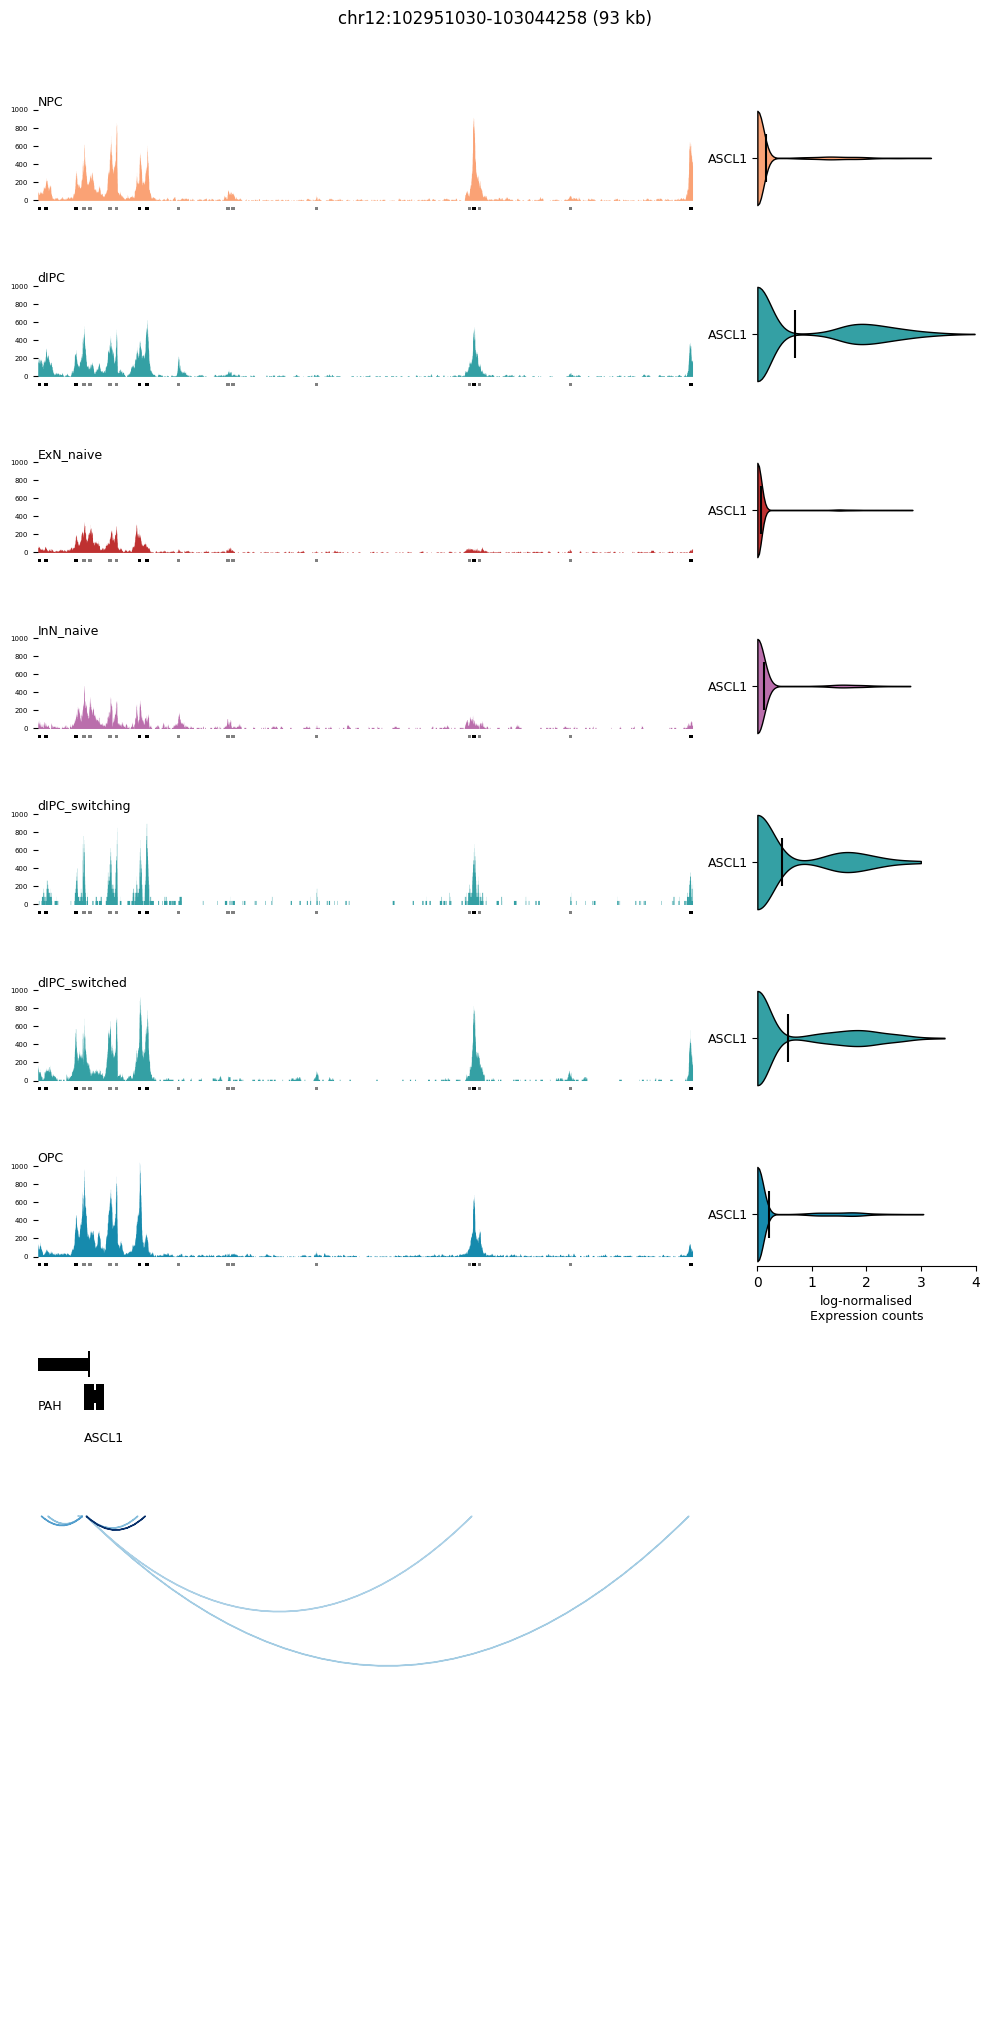

In [16]:
# Plot
%load_ext autoreload
%autoreload 2

from importlib import reload
from scenicplus.plotting.coverageplot import *


fig = coverage_plot(
        SCENICPLUS_obj = scplus_obj,
        bw_dict = bw_dict_toshow,
        region = region, 
        figsize = (10,20),
        pr_gtf = pr_gtf,
        #bw_ymax = 1000,
        color_dict = palette,
        plot_order = None,
        pr_interact = interact_gene, #interact_gene, # pr_interact, 
        genes_violin_plot = [genes_violin_plot],
        meta_data_key = 'celltype', #'ACC_Seurat_cell_type',
        pr_consensus_bed = bed_with_name,
        region_bed_height = 30,
        fontsize_dict={'bigwig_label': 9, 'bigwig_tick_label': 5, 'gene_label': 9, 'title': 12, 'violinplots_xlabel': 9, 'violinplots_ylabel': 9},
        height_ratios_dict = {'bigwig_violin': 1, 'genes': 1, 'arcs': 5},
        gene_height= 2,
        exon_height = 4
        )

plt.tight_layout()
plt.savefig(f'./plot/{genes_violin_plot}_coverage_plot_0.04.pdf', dpi=600, bbox_inches='tight')